# 28.1 · Single-stage localization mechanics

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain single-stage localization mechanics using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[27 · Object Detection](../../27-object-detection/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

YOLO-family detectors predict objects efficiently from shared image features. The exact head, assignment, loss and suppression behavior varies by version. Learn the box and training mechanics first, then use an explicit model configuration for the full library workflow.

## 2. Intuition

A dense detector learns location and category predictions from spatial features at one or more scales. Early YOLO used a grid-based formulation; newer families change important details. The CPU lab trains a single-object box regressor to expose normalized target encoding and localization loss. It is intentionally not a reproduction of a named YOLO architecture.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 28
LESSON = 0
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
c_x=(x_1+x_2)/(2W),\quad w=(x_2-x_1)/W
$$

x1,x2 are horizontal corners and W image width; cx and w are normalized center and width. For corners 20 and 60 in a 100-pixel image, cx=0.4 and w=0.4.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
x1, x2, width = 20.0, 60.0, 100.0
center_x = (x1 + x2) / (2 * width)
box_width = (x2 - x1) / width
assert np.allclose([center_x, box_width], [0.4, 0.4])
print(center_x, box_width)

0.4 0.4


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The local regressor predicts normalized cxcywh with a sigmoid and trains against boxes derived from generated masks. Full detector stages are implemented in the optional external workflow and are not executed by default.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def yolo_grid(lesson, seed, amount):
    configure(seed)
    x, _, masks = shape_data(64, size=24, seed=seed)
    targets = []
    for mask in masks[:, 0].numpy():
        yy, xx = np.nonzero(mask)
        targets.append(
            [
                (xx.min() + xx.max() + 1) / 48,
                (yy.min() + yy.max() + 1) / 48,
                (xx.max() - xx.min() + 1) / 24,
                (yy.max() - yy.min() + 1) / 24,
            ]
        )
    targets = torch.tensor(targets)
    model = nn.Sequential(
        nn.Conv2d(1, 8, 3, padding=1),
        nn.ReLU(),
        nn.Flatten(),
        nn.Linear(8 * 24 * 24, 4),
        nn.Sigmoid(),
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=0.004 * amount)
    losses = []
    for _ in range(30):
        prediction = model(x)
        loss = F.smooth_l1_loss(prediction, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(float(loss.detach()))
    test, _, test_masks = shape_data(6, size=24, seed=seed + 999)
    with torch.no_grad():
        box = model(test)[0].numpy()
    canvas = cv2.cvtColor((test[0, 0].numpy() * 255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
    cx, cy, w, h = box * 24
    cv2.rectangle(
        canvas,
        (int(cx - w / 2), int(cy - h / 2)),
        (int(cx + w / 2), int(cy + h / 2)),
        (255, 80, 40),
        1,
    )
    return Result(
        "28 · Single-shot box regression before full YOLO",
        {"Unseen synthetic input and predicted box": canvas, "Training mask": masks[0, 0].numpy()},
        curves={"Training box loss": losses},
        metrics={
            "predicted_normalized_cxcywh": box.tolist(),
            "training_samples": 64,
            "updates": 30,
        },
        notes="A four-output didactic single-object regressor, NOT an implementation of Ultralytics YOLO. The included YOLO CLI performs actual dataset validation, train, val, predict and export with an optional installation.",
    )

{
  "predicted_normalized_cxcywh": [
    0.6779366731643677,
    0.5954762101173401,
    0.47425997257232666,
    0.4745725989341736
  ],
  "training_samples": 64,
  "updates": 30
}
A four-output didactic single-object regressor, NOT an implementation of Ultralytics YOLO. The included YOLO CLI performs actual dataset validation, train, val, predict and export with an optional installation.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/numerics.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.numerics import iou

display(Code(inspect.getsource(iou), language="python"))

def iou(box, others):
    """Continuous xyxy boxes with exclusive extent; broadcast against N boxes."""
    box, others = np.asarray(box, float), np.asarray(others, float).reshape(-1, 4)
    intersection = np.maximum(
        0, np.minimum(box[2:], others[:, 2:]) - np.maximum(box[:2], others[:, :2])
    ).prod(1)
    area_a = np.maximum(0, box[2:] - box[:2]).prod()
    area_b = np.maximum(0, others[:, 2:] - others[:, :2]).prod(1)
    return intersection / np.maximum(area_a + area_b - intersection, 1e-12)

## 8. Experiment

Inspect every generated label as an overlay, then intentionally introduce an invalid width and confirm that validation rejects it.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "predicted_normalized_cxcywh": [
      0.6779366731643677,
      0.5954762101173401,
      0.47425997257232666,
      0.4745725989341736
    ],
    "training_samples": 64,
    "updates": 30
  },
  "second_seed": {
    "predicted_normalized_cxcywh": [
      0.6057141423225403,
      0.46127849817276,
      0.3671616017818451,
      0.3895578980445862
    ],
    "training_samples": 64,
    "updates": 30
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

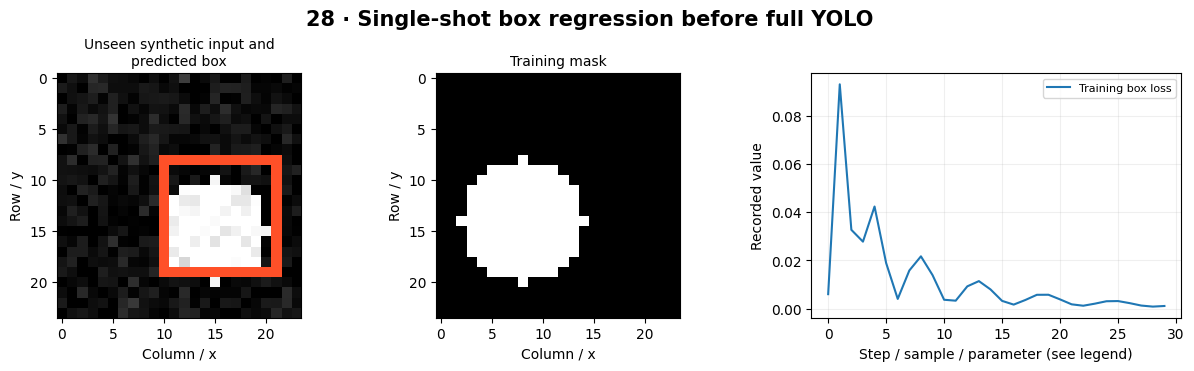

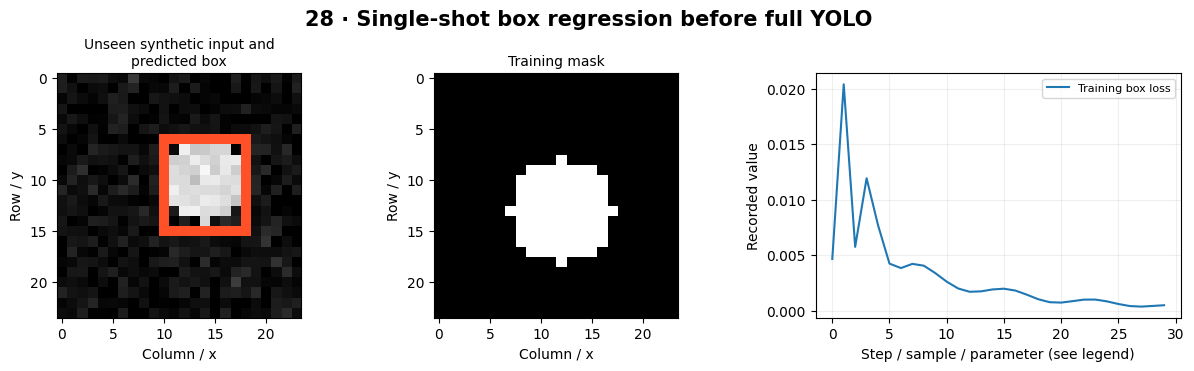

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Custom YOLO Detector**. Run an auditable custom detector workflow. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

Training and test images from adjacent video frames can leak scene content. A synthetic regressor loss must not be advertised as YOLO mAP.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Inspect every generated label as an overlay, then intentionally introduce an invalid width and confirm that validation rejects it.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Train a custom detector on a documented dataset, produce per-class errors and export a model whose outputs match the training runtime.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

A dense detector learns location and category predictions from spatial features at one or more scales. Early YOLO used a grid-based formulation; newer families change important details. The CPU lab trains a single-object box regressor to expose normalized target encoding and localization loss. It is intentionally not a reproduction of a named YOLO architecture.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

Continue with **Dataset preparation and annotation checks** in this chapter.

[Primary reference](https://docs.ultralytics.com/modes/train/) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)